In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from ipywidgets import interact, FloatSlider

### Cash-or-Nothing Binary Option

**Definition**
A digital option that pays a fixed cash amount ($C$) if the asset finishes above the strike price ($K$), regardless of how high the price goes.

**Payoff Formula**
$$
\text{Payoff}(S_T) = C \cdot \mathbb{1}_{\{S_T > K\}}
$$


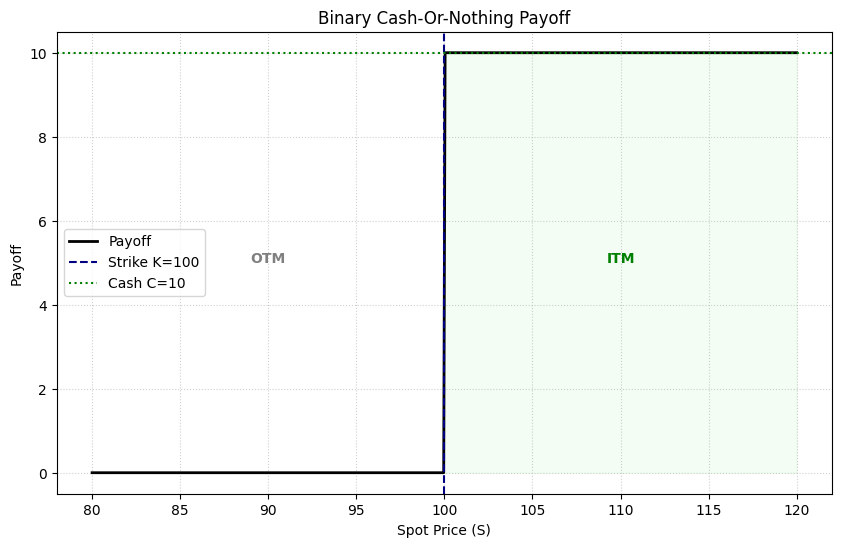

In [3]:
def binary_option_payoff(S, K, C):
    return np.where(S > K, C, 0)

S = np.linspace(80, 120, 500)
K, C = 100, 10
plt.figure(figsize=(10, 6))

# Plot
plt.plot(S, binary_option_payoff(S, K, C), color='black', linewidth=2, label='Payoff')
plt.fill_between(S, binary_option_payoff(S, K, C), 0, alpha=0.1, color='lightgreen')

# Reference Lines
plt.axvline(K, color='navy', linestyle='--', label=f'Strike K={K}')
plt.axhline(C, color='green', linestyle=':', label=f'Cash C={C}')

# Grid & Labels
plt.grid(True, linestyle=':', alpha=0.6) # Explicit grid
plt.title('Binary Cash-Or-Nothing Payoff')
plt.xlabel('Spot Price (S)')
plt.ylabel('Payoff')

# Text Labels (ITM/OTM)
plt.text(90, 5, "OTM", ha='center', color='gray', fontweight='bold')
plt.text(110, 5, "ITM", ha='center', color='green', fontweight='bold')
plt.legend()
plt.show()


### Pricing Formula (Black-Scholes)

The Present Value ($PV$) of a Cash-or-Nothing Call is the discounted cash amount multiplied by the probability of finishing in-the-money (under the risk-neutral measure):

$$
PV = C \cdot e^{-rT} \cdot N(d_2)
$$

Where:
$$
d_2 = \frac{\ln(S/K) + (r - \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}
$$

$N(d_2)$ is the probability of finishing in-the-money (under the risk-neutral measure) for a call option.


<>:43: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:43: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/z2/8m1s5xtd2856rcnbnsk5jmr00000gn/T/ipykernel_26168/4238688919.py:43: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.title(f'Binary Option Price (PV) vs Spot Price\n($\sigma={sigma}, r={r}, C={C}$)')


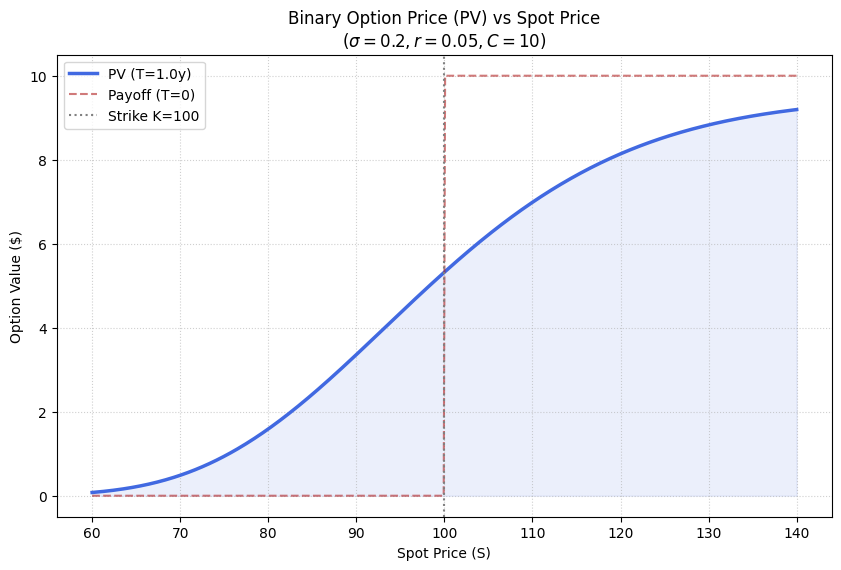

In [4]:
def binary_call_price(S, K, T, r, sigma, C=10):
    """
    Calculates the Price of a Cash-or-Nothing Binary Call Option.
    
    Parameters:
    S : float : Spot Price
    K : float : Strike Price
    T : float : Time to Maturity (in years)
    r : float : Risk-free rate (decimal, e.g., 0.05 for 5%)
    sigma : float : Volatility (decimal, e.g., 0.2 for 20%)
    C : float : Cash Payout Amount
    """
    # Avoid division by zero if T is 0
    if T <= 0:
        return np.where(S > K, C, 0)
    
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    
    price = C * np.exp(-r * T) * norm.cdf(d2)
    return price

# Parameters
K = 100         # Strike
C = 10          # Cash Payout
r = 0.05        # Risk-free rate (5%)
sigma = 0.2     # Volatility (20%)
T = 1.0         # 1 Year to maturity
S = np.linspace(60, 140, 500)
# 1. Calculate Prices (PV) using your function
pv = binary_call_price(S, K, T, r, sigma, C)
# 2. Calculate Payoff (Maturity T=0) for comparison
payoff = binary_call_price(S, K, 0, r, sigma, C) 
plt.figure(figsize=(10, 6))
# Plot PV (Price today)
plt.plot(S, pv, color='royalblue', linewidth=2.5, label=f'PV (T={T}y)')
plt.fill_between(S, pv, 0, color='royalblue', alpha=0.1)
# Plot Payoff (Reference)
plt.plot(S, payoff, color='firebrick', linestyle='--', linewidth=1.5, alpha=0.6, label='Payoff (T=0)')
# Reference Lines
plt.axvline(K, color='gray', linestyle=':', label=f'Strike K={K}')
# Grid & Labels
plt.grid(True, linestyle=':', alpha=0.6)
plt.title(f'Binary Option Price (PV) vs Spot Price\n($\sigma={sigma}, r={r}, C={C}$)')
plt.xlabel('Spot Price (S)')
plt.ylabel('Option Value ($)')
plt.legend()
plt.show()



### Digital Call Delta

**Exact Formula**
$$
\Delta_{\text{binary}} = \frac{C \cdot e^{-rT} \cdot N'(d_2)}{\sigma S \sqrt{T}}
$$

**Relation to Vanilla Gamma**
This is mathematically equivalent to the Gamma of a vanilla call (scaled):
$$
\Delta_{\text{binary}} = C \cdot \frac{S}{K} \cdot \Gamma_{\text{vanilla}}
$$

**Behavior**
*   **Peaks at Strike**: The sensitivity is maximal exactly at the barrier ($K$).

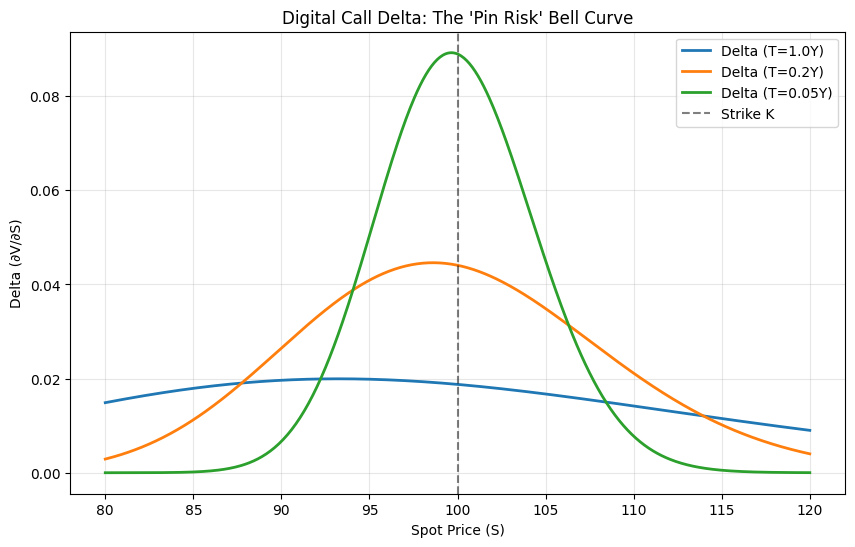

In [5]:
def digital_call_delta(S, K, T, r, sigma):
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    # Formula: e^(-rT) * n(d2) / (S * sigma * sqrt(T))
    delta = np.exp(-r * T) * norm.pdf(d2) / (S * sigma * np.sqrt(T))
    return delta

# Parameters
K = 100
r = 0.05
sigma = 0.20
S = np.linspace(80, 120, 500)
maturities = [1.0, 0.2, 0.05] # 1 year, ~2.5 months, ~2 weeks

plt.figure(figsize=(10, 6))

for T in maturities:
    deltas = digital_call_delta(S, K, T, r, sigma)
    plt.plot(S, deltas, label=f'Delta (T={T}Y)', lw=2)

plt.axvline(K, color='black', linestyle='--', alpha=0.5, label='Strike K')
plt.title("Digital Call Delta: The 'Pin Risk' Bell Curve")
plt.xlabel("Spot Price (S)")
plt.ylabel("Delta (∂V/∂S)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Dirac Behavior ($T \to 0$)**
As time to maturity vanishes, the Delta essentially becomes a **Dirac Delta function**:
$$
\lim_{T \to 0} \Delta_{\text{binary}} \approx \delta(S-K)
$$
*   **At $S=K$**: Delta $\to \infty$. 
*   **Everywhere else**: Delta $\to 0$.


Below : interactive plot to see the behaviour of delta as delta approaches maturity.

In [ ]:
def plot_true_expiry(t=0.0):
    T_maturity = 1.0
    tau = T_maturity - t
    
    K, C = 100, 10
    r, sigma = 0.05, 0.2
    S = np.linspace(80, 120, 2000)
    
    delta_vals = digital_call_delta(S, K, tau, r, sigma)
    peak_delta = np.max(delta_vals)
    
    plt.figure(figsize=(10, 6))
    plt.plot(S, delta_vals, color='crimson', linewidth=2)
    
    plt.xlim(80, 120)
    # No ylim set; it will auto-scale to show the massive spike
    
    plt.title(f"Approaching Expiry: $\\tau = {tau:.5f}$ years left\nMax Delta = {peak_delta:,.0f}", fontsize=14, fontweight='bold')
    plt.xlabel('Spot Price')
    plt.ylabel('Delta')
    plt.show()

# High Precision Slider
interact(plot_true_expiry, 
         t=FloatSlider(min=0.0, max=0.99999, step=0.00001, value=0.9, readout_format='.5f', description='Time (t)'));

interactive(children=(FloatSlider(value=0.9, description='Time (t)', max=0.99999, readout_format='.5f', step=1…

### Binary Put Option (Cash-or-Nothing)

**1. Payoff**
Pays cash amount $C$ if the spot ends *below* the strike.
$$
\text{Payoff} = C \cdot \mathbb{1}_{\{S_T < K\}}
$$

**2. Price (Present Value)**
$$
PV = C \cdot e^{-rT} \cdot N(-d_2)
$$
*Since $N(-d_2)$ is the probability of finishing ITM (below K) under risk-neutral measure*

**3. Delta**
Sensitivity is negative (price drops as spot rises).
$$
\Delta_{\text{put}} = - \frac{C \cdot e^{-rT} \cdot N'(d_2)}{\sigma S \sqrt{T}}
$$
*Note: This is exactly $-\Delta_{\text{call}}$.*

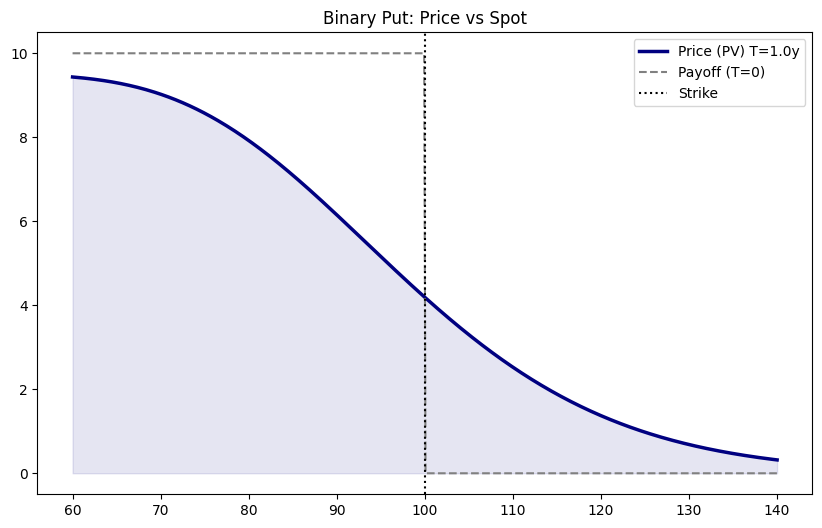

In [7]:
def binary_put_price(S, K, T, r, sigma, C=10):
    d2 = (np.log(S/K) + (r - 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return C * np.exp(-r*T) * norm.cdf(-d2)

# Parameters
S = np.linspace(60, 140, 500)
K, C = 100, 10
r, sigma, T = 0.05, 0.2, 1.0

# Calculate
price = binary_put_price(S, K, T, r, sigma, C)
payoff = np.where(S < K, C, 0)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(S, price, color='navy', linewidth=2.5, label=f'Price (PV) T={T}y')
plt.plot(S, payoff, color='gray', linestyle='--', linewidth=1.5, label='Payoff (T=0)')
plt.fill_between(S, price, 0, color='navy', alpha=0.1)

plt.axvline(K, color='black', linestyle=':', label='Strike')
plt.title('Binary Put: Price vs Spot')
plt.legend()
plt.show()

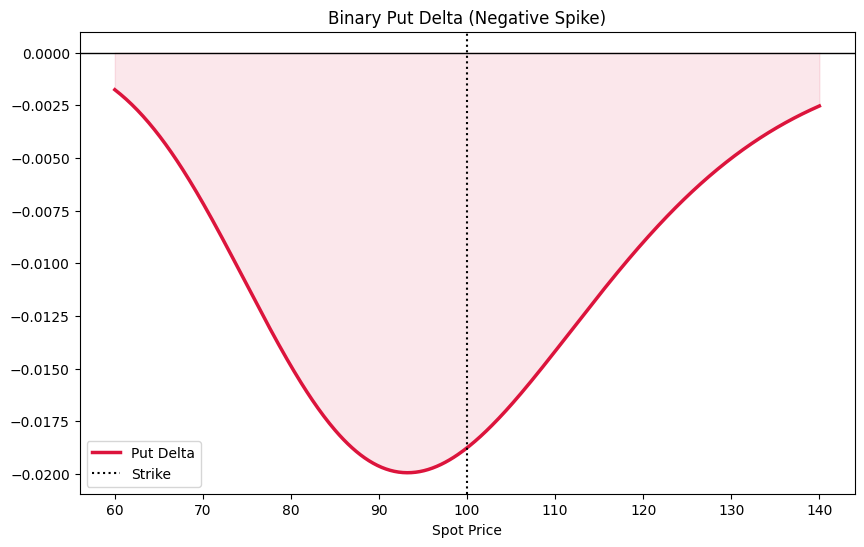

In [8]:
# Calculate Delta numerically or analytically
# Using analytic formula for consistency
d2 = (np.log(S/K) + (r - 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
delta = -digital_call_delta(S,K,T,r,sigma)

plt.figure(figsize=(10, 6))
plt.plot(S, delta, color='crimson', linewidth=2.5, label='Put Delta')
plt.fill_between(S, delta, 0, color='crimson', alpha=0.1)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(K, color='black', linestyle=':', label='Strike')

plt.title('Binary Put Delta (Negative Spike)')
plt.xlabel('Spot Price')
plt.legend()
plt.show()

### Binary Call Vega ($\mathcal{V}$)

**Sensitivity to Volatility**
Vega measures how the binary price changes when volatility ($\sigma$) increases.

$$
\mathcal{V}_{\text{binary}} = \frac{\partial V}{\partial \sigma} = -C \cdot e^{-rT} \cdot N'(d_2) \cdot \frac{d_2}{\sigma}
$$

**Key Insight**
*   Unlike vanilla options (where Vega is always positive), Binary Option Vega **can be negative**.
*   **If ITM ($S > K \implies d_2 > 0$)**: Vega is **negative**. Higher vol increases the chance of falling OTM.
*   **If OTM ($S < K \implies d_2 < 0$)**: Vega is **positive**. Higher vol increases the chance of reaching ITM.

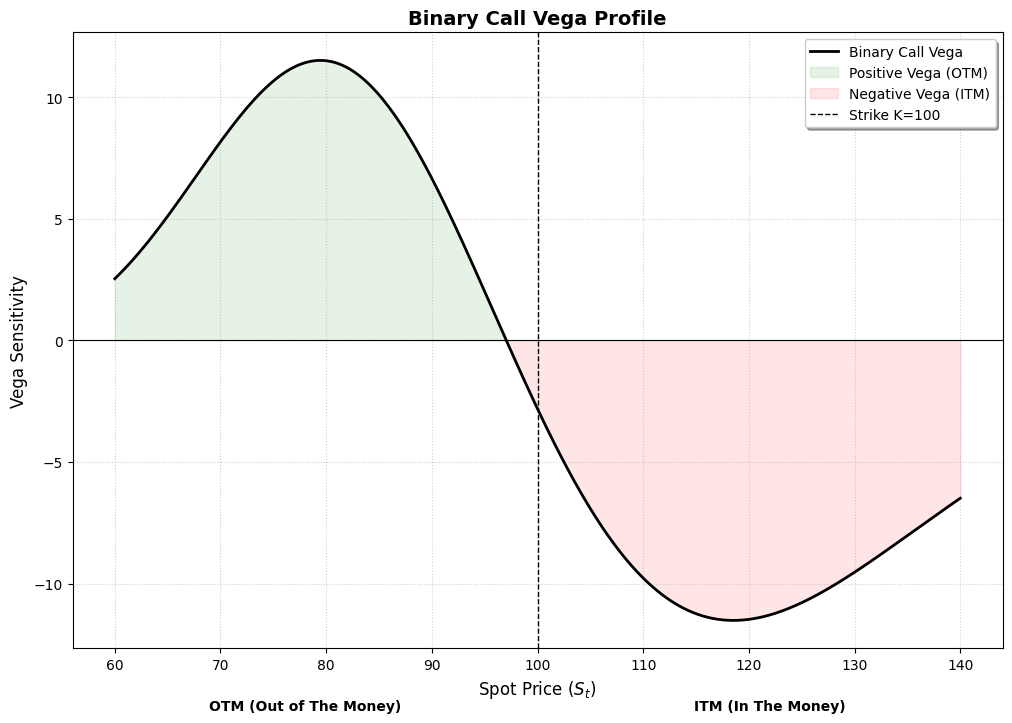

In [9]:
#Testing a new template to plot smooth plots

d2 = (np.log(S/K) + (r - 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

def vega_digital_call(S,K,T,r,sigma,C) :
    return -C*np.exp(-r*T)*norm.pdf(d2)*d2/sigma

# Parameters
S = np.linspace(60, 140, 500)
K, C = 100, 10
r, sigma, T = 0.05, 0.2, 1.
vega=vega_digital_call(S,K,T,r,sigma,C)


plt.figure(figsize=(12, 8)) # Setup the canvas size

# 1. Main Plot
plt.plot(S, vega, color='black', linewidth=2, label='Binary Call Vega')

# 2. Visual Enhancements (Fill areas)
plt.fill_between(S, vega, 0, where=(vega > 0), color='green', alpha=0.1, label='Positive Vega (OTM)')
plt.fill_between(S, vega, 0, where=(vega < 0), color='red', alpha=0.1, label='Negative Vega (ITM)')

# 3. Reference Lines
plt.axvline(x=K, color='black', linestyle='--', linewidth=1, label=f'Strike K={K}')
plt.axhline(y=0, color='black', linewidth=0.8) # Zero line

plt.title('Binary Call Vega Profile', fontsize=14, fontweight='bold')
plt.xlabel('Spot Price ($S_t$)', fontsize=12)
plt.ylabel('Vega Sensitivity', fontsize=12)
plt.grid(visible=True, linestyle=':', alpha=0.6)

# Text Labels (ITM/OTM)
ax = plt.gca() # Get current axis to use relative coordinates
# Place labels below the axis (y = -0.1 in axis coordinates)
plt.text(0.25, -0.1, "OTM (Out of The Money)", 
         transform=ax.transAxes, ha='center', color='black', fontweight='bold')
plt.text(0.75, -0.1, "ITM (In The Money)", 
         transform=ax.transAxes, ha='center', color='black', fontweight='bold')

# 5. Legend
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.show()

### Binary Put Vega ($\mathcal{V}$)

**Sensitivity to Volatility**
Vega measures how the binary put price changes when volatility ($\sigma$) increases.

$$
\mathcal{V}_{\text{binary put}} = C \cdot e^{-rT} \cdot N'(d_2) \cdot \frac{d_2}{\sigma}
$$

**Key Insight**
*   **If OTM ($S > K \implies d_2 > 0$)**: Vega is **positive**. Higher vol increases the chance of falling ITM (Put pays if implementation is below K).
*   **If ITM ($S < K \implies d_2 < 0$)**: Vega is **negative**. Higher vol increases the chance of rising OTM.

*Note: This is exactly $-\mathcal{V}_{\text{binary call}}$.*

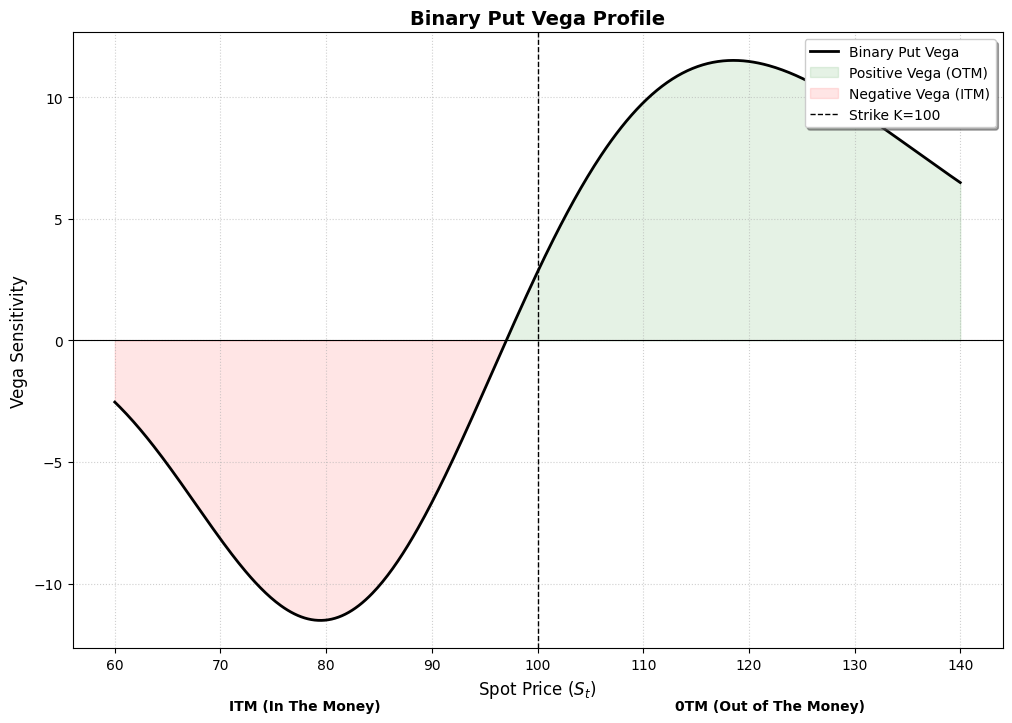

In [10]:
# Parameters
S = np.linspace(60, 140, 500)
K, C = 100, 10
r, sigma, T = 0.05, 0.2, 1.
vega_digital_put=-vega_digital_call(S,K,T,r,sigma,C)


plt.figure(figsize=(12, 8)) # Setup the canvas size

# 1. Main Plot
plt.plot(S, vega_digital_put, color='black', linewidth=2, label='Binary Put Vega')

# 2. Visual Enhancements (Fill areas)
plt.fill_between(S, vega_digital_put, 0, where=(vega < 0), color='green', alpha=0.1, label='Positive Vega (OTM)')
plt.fill_between(S, vega_digital_put, 0, where=(vega > 0), color='red', alpha=0.1, label='Negative Vega (ITM)')

# 3. Reference Lines
plt.axvline(x=K, color='black', linestyle='--', linewidth=1, label=f'Strike K={K}')
plt.axhline(y=0, color='black', linewidth=0.8) # Zero line

plt.title('Binary Put Vega Profile', fontsize=14, fontweight='bold')
plt.xlabel('Spot Price ($S_t$)', fontsize=12)
plt.ylabel('Vega Sensitivity', fontsize=12)
plt.grid(visible=True, linestyle=':', alpha=0.6)

# Text Labels (ITM/OTM)
ax = plt.gca() # Get current axis to use relative coordinates
# Place labels below the axis (y = -0.1 in axis coordinates)
plt.text(0.25, -0.1, "ITM (In The Money)", 
         transform=ax.transAxes, ha='center', color='black', fontweight='bold')
plt.text(0.75, -0.1, "0TM (Out of The Money)", 
         transform=ax.transAxes, ha='center', color='black', fontweight='bold')

# 5. Legend
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.show()

### Digital Call Gamma ($\Gamma$)

**Formula**
$$
\Gamma_{\text{binary call}} = -\frac{C \cdot e^{-rT} \cdot N'(d_2) \cdot d_1}{\sigma^2 S^2 T}
$$

**Behavior**
*   **Dipole Pattern**: Gamma is **positive** just before the strike and **negative** just after.
*   **Zero at Strike**: At exactly $S = K$, Gamma crosses through zero.
*   **Hedging Risk**: This sign flip makes gamma hedging extremely unstable near expiry.

In [11]:
def gamma_digital_call(S, K, T, r, sigma, C=10):
    """
    Calculate Gamma of a Cash-or-Nothing Binary Call
    """
    if T <= 1e-6: T = 1e-6  # Avoid division by zero
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = (np.log(S/K) + (r - 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    
    # Gamma formula
    gamma = -(C * np.exp(-r*T) * norm.pdf(d2) * d1) / (sigma**2 * S**2 * T)
    return gamma

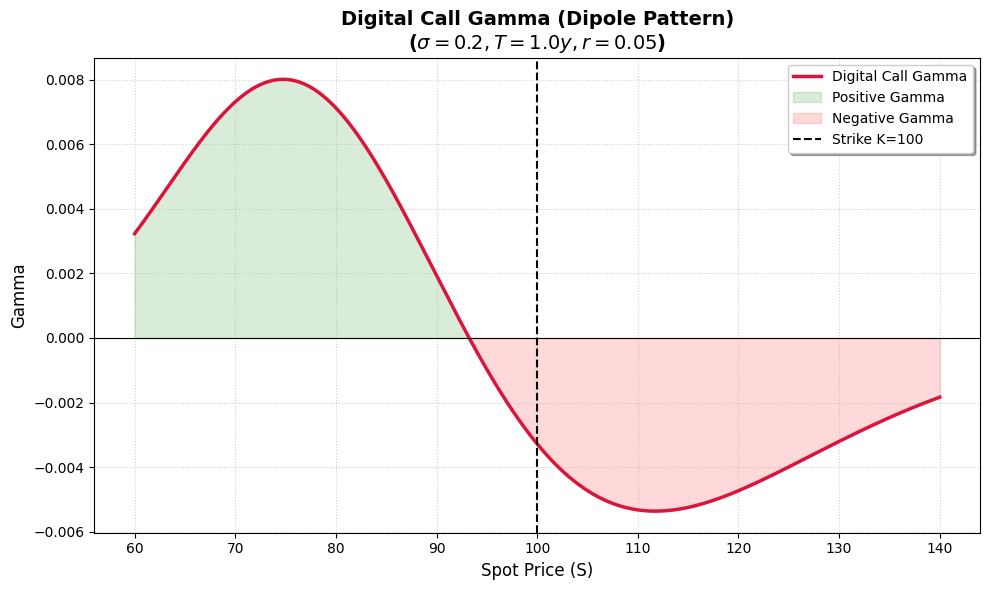

In [12]:
S = np.linspace(60, 140, 2000)
K, T, r, sigma, C = 100, 1.0, 0.05, 0.2, 10

gamma_digital_c= gamma_digital_call(S, K, T, r, sigma, C)

plt.figure(figsize=(10, 6))

# Main plot
plt.plot(S, gamma_digital_c, color='crimson', linewidth=2.5, label='Digital Call Gamma')
plt.fill_between(S, gamma_digital_c, 0, where=(gamma_digital_c > 0), color='green', alpha=0.15, label='Positive Gamma')
plt.fill_between(S, gamma_digital_c, 0, where=(gamma_digital_c < 0), color='red', alpha=0.15, label='Negative Gamma')

# Reference lines
plt.axvline(K, color='black', linestyle='--', linewidth=1.5, label=f'Strike K={K}')
plt.axhline(0, color='black', linewidth=0.8)

# Styling
plt.grid(True, linestyle=':', alpha=0.6)
plt.title(f'Digital Call Gamma (Dipole Pattern)\n($\\sigma={sigma}, T={T}y, r={r}$)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Spot Price (S)', fontsize=12)
plt.ylabel('Gamma', fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### Digital Put Gamma ($\Gamma$)

**Formula**
$$
\Gamma_{\text{binary put}} = \frac{C \cdot e^{-rT} \cdot N'(d_2) \cdot d_1}{\sigma^2 S^2 T}
$$

**Behavior**
*   **Opposite Dipole**: Gamma is **negative** before the strike and **positive** after.
*   This is exactly $-\Gamma_{\text{binary call}}$.

### Relationship: Vanilla vs. Digital Greeks

| Vanilla Greek | Digital Greek (Equivalent Behavior) |
| :--- | :--- |
| **Delta** ($\Delta_V$) | $\approx$ **Price** of Digital (S-shaped curve) |
| **Gamma** ($\Gamma_V$) | $\approx$ **Delta** of Digital (Bell curve) |
| **Speed** ($d\Gamma_V/dS$) | $\approx$ **Gamma** of Digital (Dipole/Sign flip) |
| **Vanna** ($d\Delta_V/d\sigma$) | $\approx$ **Vega** of Digital (Sign flip) |

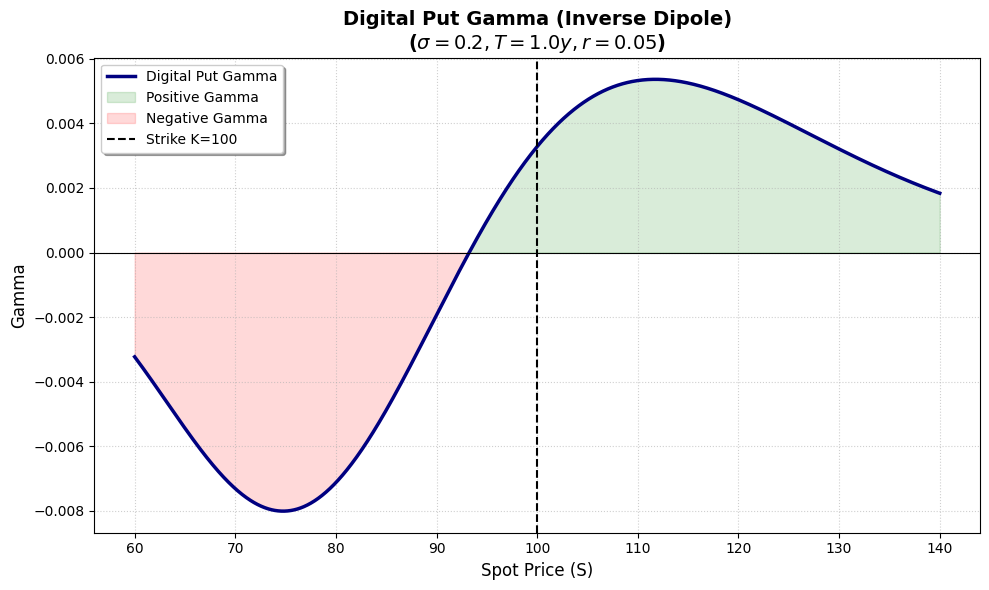

In [13]:
S = np.linspace(60, 140, 2000)
K, T, r, sigma, C = 100, 1.0, 0.05, 0.2, 10


# Digital Put Gamma = -Digital Call Gamma
gamma_digital_put = -gamma_digital_call(S, K, T, r, sigma, C)

plt.figure(figsize=(10, 6))

# Main plot
plt.plot(S, gamma_digital_put, color='navy', linewidth=2.5, label='Digital Put Gamma')
plt.fill_between(S, gamma_digital_put, 0, where=(gamma_digital_put > 0), color='green', alpha=0.15, label='Positive Gamma')
plt.fill_between(S, gamma_digital_put, 0, where=(gamma_digital_put < 0), color='red', alpha=0.15, label='Negative Gamma')

# Reference lines
plt.axvline(K, color='black', linestyle='--', linewidth=1.5, label=f'Strike K={K}')
plt.axhline(0, color='black', linewidth=0.8)

# Styling
plt.grid(True, linestyle=':', alpha=0.6)
plt.title(f'Digital Put Gamma (Inverse Dipole)\n($\\sigma={sigma}, T={T}y, r={r}$)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Spot Price (S)', fontsize=12)
plt.ylabel('Gamma', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### Binary Range Option

A **range binary** pays a fixed amount ($C$) if the spot price finishes between two strikes ($K_1 < S_T < K_2$), otherwise zero. It's constructed by buying a digital call at $K_1$ and selling a digital call at $K_2$.

$$\text{Payoff} = C \cdot \left(\mathbb{1}_{\{S_T > K_1\}} - \mathbb{1}_{\{S_T > K_2\}}\right)$$

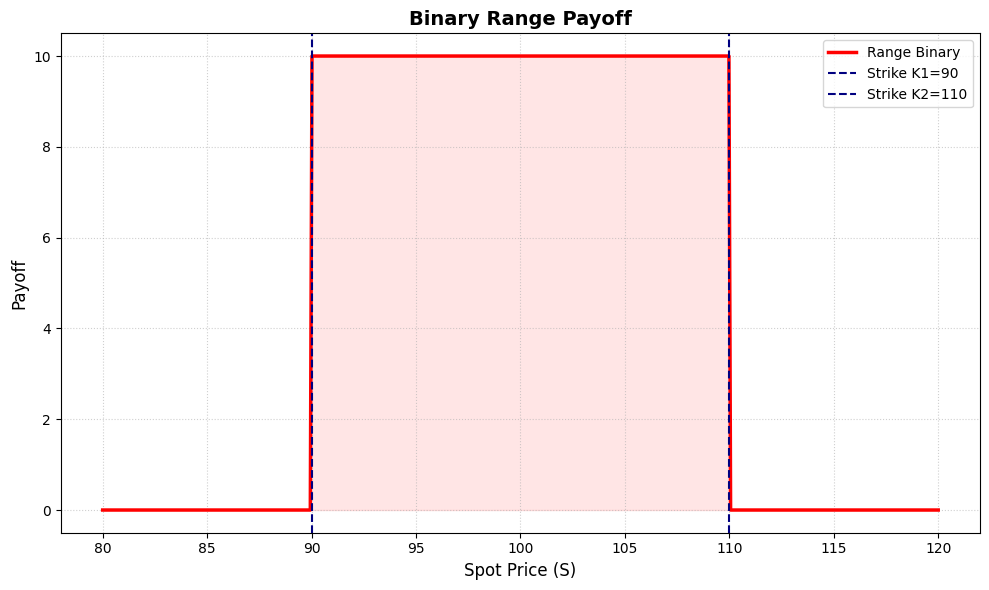

In [14]:
S=np.linspace(80,120,500)
K1=90
K2=110
C=10

d_call_1=binary_option_payoff(S,K1,C)
d_call_2=binary_option_payoff(S,K2,C)

range_binary=d_call_1-d_call_2  

plt.figure(figsize=(10, 6))
plt.plot(S, range_binary, color="red", linewidth=2.5, label="Range Binary", antialiased=True)
plt.fill_between(S, range_binary, 0, color='red', alpha=0.1)

plt.axvline(K1, color='navy', linestyle='--', linewidth=1.5, label=f'Strike K1={K1}')
plt.axvline(K2, color='navy', linestyle='--', linewidth=1.5, label=f'Strike K2={K2}')

plt.grid(True, linestyle=':', alpha=0.6)
plt.title('Binary Range Payoff', fontsize=14, fontweight='bold')
plt.xlabel('Spot Price (S)', fontsize=12)
plt.ylabel('Payoff', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

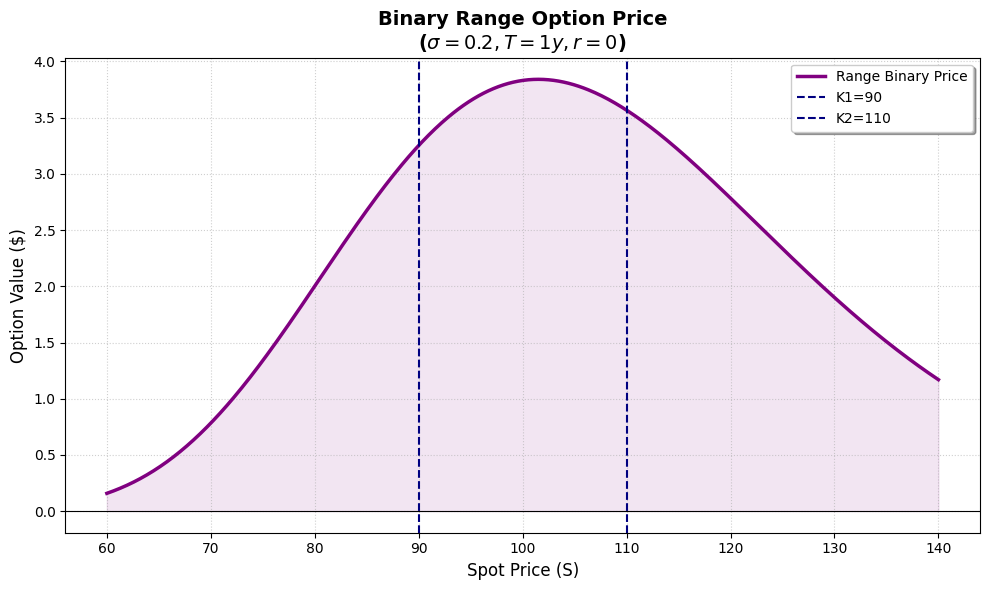

In [15]:
S=np.linspace(60,140,500)
K1=90
K2=110
T=1
r=0
sigma=0.2
C=10

price_call_1=binary_call_price(S,K1,T,r,sigma,C)
price_call_2=binary_call_price(S,K2,T,r,sigma,C)
range_price=price_call_1-price_call_2


plt.figure(figsize=(10, 6))
# Main plot
plt.plot(S, range_price, color='purple', linewidth=2.5, label='Range Binary Price')
plt.fill_between(S, range_price, 0, color='purple', alpha=0.1)
# Reference lines
plt.axvline(K1, color='navy', linestyle='--', linewidth=1.5, label=f'K1={K1}')
plt.axvline(K2, color='navy', linestyle='--', linewidth=1.5, label=f'K2={K2}')
plt.axhline(0, color='black', linewidth=0.8)
# Styling
plt.grid(True, linestyle=':', alpha=0.6)
plt.title(f'Binary Range Option Price\n($\\sigma={sigma}, T={T}y, r={r}$)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Spot Price (S)', fontsize=12)
plt.ylabel('Option Value ($)', fontsize=12)
plt.legend(loc='best', frameon=True, shadow=True)
plt.tight_layout()
plt.show()